# Sona: learning song mood from audio features

An executable recreation of [Moodify by cayetana-h and contributors](https://github.com/cayetana-h/Moodify/tree/f0596bbf19567b2400924b3c172dfb806eabae02), with rewritten training, evaluation, and inference. See the repository's `LICENSE` and `NOTICE` for attribution.

The experiment has two stages: cluster songs using **valence, energy, and acousticness**, then train a classifier to recover those groups from other audio features. The five mood names are interpretations of those clusters. **They are not human-validated emotion labels.**

This notebook uses the bundled CSV, needs no credentials or network calls, and trains on a reproducible sample of 10,000 cleaned tracks. Install the project and development dependencies before opening it (`pip install -e ".[dev]"` from the repository root). Run all cells in order; no input prompts are used.


In [1]:
from pathlib import Path
import json
import sys

# Works when the notebook starts in the repository root or notebooks/.
ROOT = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent / "data" / "SpotifyFeatures.csv").is_file()
     and (parent / "sona" / "__init__.py").is_file()),
    None,
)
if ROOT is None:
    raise RuntimeError("Open this notebook from the Sona repository or its notebooks folder.")
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from sona import train, load_bundle, predict_df

DATA_PATH = ROOT / "data" / "SpotifyFeatures.csv"
ARTIFACT_DIR = ROOT / "artifacts-notebook"
SEED = 42
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})
print(f"Repository: {ROOT.name}")


Repository: sona


## 1. Inspect the source data

The source CSV contains track metadata and precomputed audio descriptors, not recordings. A single track may occur in multiple genre listings, so the number of rows is larger than the number of distinct track IDs. We inspect that difference before modeling. The original repository does not supply a separate dataset license or complete collection record; see `data/README.md` for the exact source revision and checksum.


In [2]:
raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
summary = pd.DataFrame({
    "measure": ["Rows", "Distinct track IDs", "Repeated track ID rows", "Comedy rows", "Missing cells"],
    "value": [len(raw), raw["track_id"].nunique(), raw["track_id"].duplicated().sum(),
              raw["genre"].eq("Comedy").sum(), raw.isna().sum().sum()],
})
display(summary)
display(raw.head(5))


,measure,value
0,Rows,232725
1,Distinct track IDs,176774
2,Repeated track ID rows,55951
3,Comedy rows,9681
4,Missing cells,1


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


## 2. Explore feature distributions

These charts describe the cleaned population before sampling. Remove Comedy and duplicate track IDs for this descriptive view. The training function performs its own required-feature validation and cleaning, so the model's recorded data counts remain authoritative.

Audio-feature distributions are useful for understanding clusters, but they do not establish how people feel when they hear a song. Loudness is in decibels and tempo is in beats per minute; the other plotted features are unit-scale descriptors.


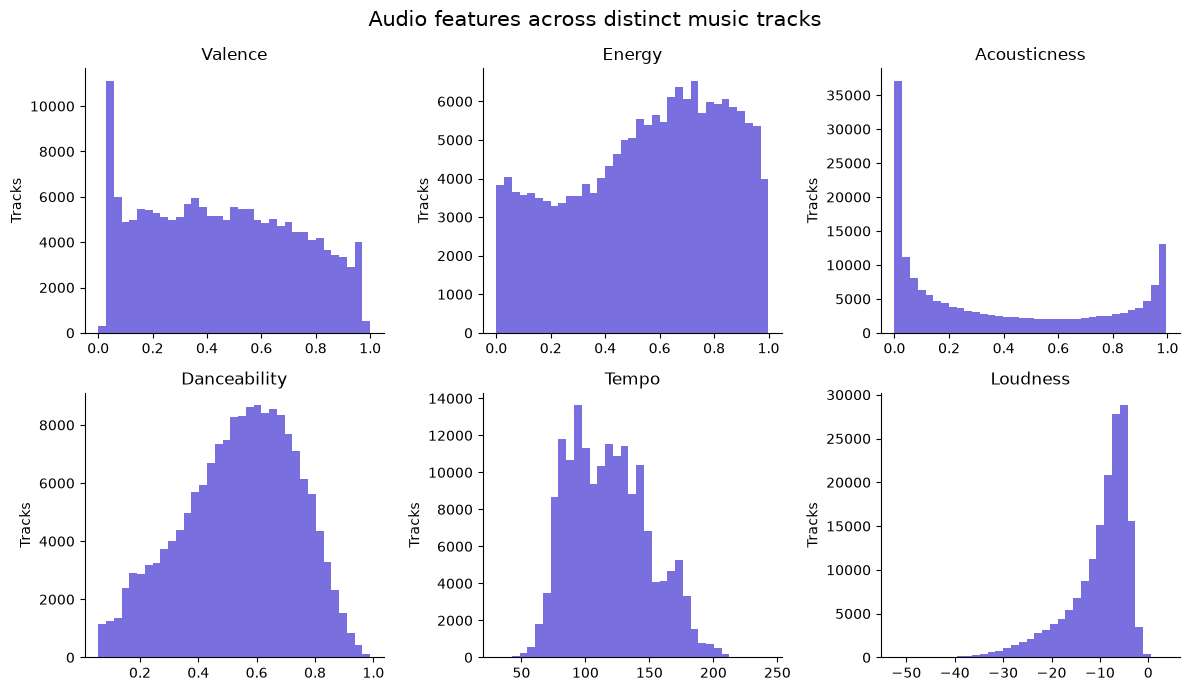

In [3]:
eda = raw.loc[raw["genre"].ne("Comedy")].drop_duplicates("track_id").copy()
features = ["valence", "energy", "acousticness", "danceability", "tempo", "loudness"]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for feature, ax in zip(features, axes.flat):
    ax.hist(eda[feature].dropna(), bins=35, color="#6256D9", alpha=0.85)
    ax.set_title(feature.replace("_", " ").title())
    ax.set_ylabel("Tracks")
fig.suptitle("Audio features across distinct music tracks", fontsize=15)
fig.tight_layout()
plt.show()


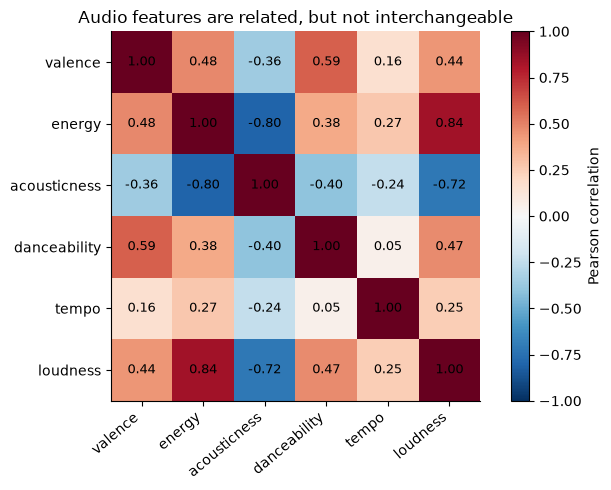

In [4]:
cluster_features = ["valence", "energy", "acousticness"]
correlation = eda[features].corr()
fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(features)), features, rotation=40, ha="right")
ax.set_yticks(range(len(features)), features)
for row in range(len(features)):
    for col in range(len(features)):
        ax.text(col, row, f"{correlation.iloc[row, col]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("Audio features are related, but not interchangeable")
fig.tight_layout()
plt.show()


## 3. Train a reproducible small experiment

The training routine deduplicates track IDs **before splitting**. It fits the clustering scaler and KMeans only on the training split, then uses that fitted clustering pipeline to label validation and test tracks. Mood names are assigned by matching learned centers to the upstream notebook's documented reference centers, rather than assuming numeric cluster IDs have stable meanings.

The classifier uses `danceability`, `instrumentalness`, `liveness`, `loudness`, `speechiness`, `tempo`, `key`, `mode`, and `time_signature`. It deliberately excludes `valence`, `energy`, and `acousticness`, which were used to construct the targets. Preprocessing is fitted with training data and saved with the classifier for consistent inference.

Candidate models are selected using **validation macro F1**. The untouched test split measures agreement with the generated cluster labels. This notebook writes its separate artifacts to `artifacts-notebook/`. Set `sample=None` in the call below to use all cleaned tracks; that takes longer.


In [5]:
metrics = train(
    DATA_PATH,
    output_dir=ARTIFACT_DIR,
    sample=10000,
    seed=SEED,
)
print("Selected model:", metrics["selected_model"])
print("Selection metric:", metrics["selection_metric"])
display(pd.Series(metrics["data"], name="count").to_frame())


[Sona] Reading C:\Users\ASUS\Documents\Codex\2026-09-18\https-github-com-cayetana-h-moodify\outputs\sona\data\SpotifyFeatures.csv
[Sona] Unique tracks: 10,000; train / validation / test: 9,000 / 500 / 500
[Sona] Training logistic_regression...
[Sona] logistic_regression: validation macro F1 = 0.5203
[Sona] Training random_forest...
[Sona] random_forest: validation macro F1 = 0.5800
[Sona] Training hist_gradient_boosting...
[Sona] hist_gradient_boosting: validation macro F1 = 0.5559
[Sona] Selected random_forest; test macro F1 = 0.5434; artifacts saved to C:\Users\ASUS\Documents\Codex\2026-09-18\https-github-com-cayetana-h-moodify\outputs\sona\artifacts-notebook
Selected model: random_forest
Selection metric: validation_macro_f1


,count
input_rows,232725
comedy_removed,9681
duplicate_tracks_removed,55943
missing_rows_removed,0
unique_tracks_available,167101
rows_used,10000
genre_column_present,True
train_rows,9000
validation_rows,500
test_rows,500


## 4. Read the evaluation

Accuracy counts the fraction of correct cluster predictions. Macro F1 gives each cluster equal weight; weighted F1 accounts for cluster frequency. Compare candidate models on validation data and interpret the test report only after model selection. The original project's reported 76.31% test accuracy is not an expected score here: this recreation changes deduplication, split hygiene, and model selection, and this notebook trains on a smaller sample.


,validation_accuracy,validation_macro_f1,validation_weighted_f1,fit_seconds
model,,,,
logistic_regression,0.550,0.5203,0.5420,0.389
random_forest,0.602,0.5800,0.5982,2.643
hist_gradient_boosting,0.584,0.5559,0.5832,2.869


,test_score
accuracy,0.5640
macro_f1,0.5434
weighted_f1,0.5595


,precision,recall,f1-score,support
Calm,0.8019,0.8586,0.8293,99.0
Content,0.3690,0.3483,0.3584,89.0
Energetic,0.5941,0.5714,0.5825,105.0
Happy,0.5355,0.5804,0.5570,143.0
Mellow,0.4259,0.3594,0.3898,64.0
macro avg,0.5453,0.5436,0.5434,500.0
weighted avg,0.5569,0.5640,0.5595,500.0


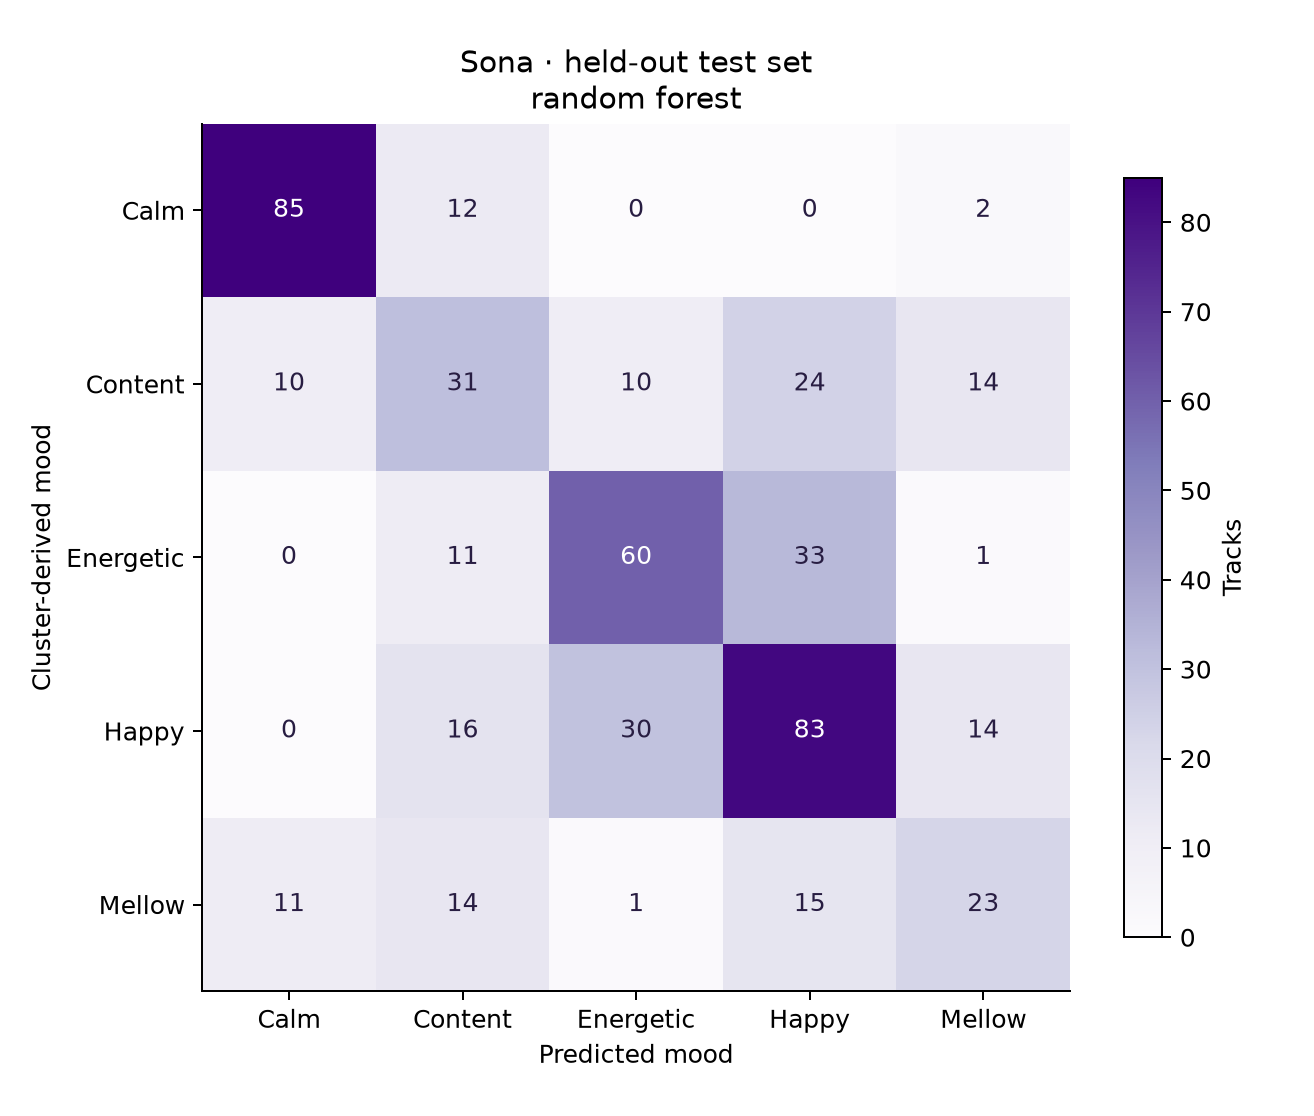

In [6]:
comparison = pd.DataFrame([
    {"model": name,
     "validation_accuracy": result["validation"]["accuracy"],
     "validation_macro_f1": result["validation"]["macro_f1"],
     "validation_weighted_f1": result["validation"]["weighted_f1"],
     "fit_seconds": result["fit_seconds"]}
    for name, result in metrics["candidates"].items()
]).set_index("model")
display(comparison.round(4))
display(pd.Series({key: metrics["test"][key]
                   for key in ["accuracy", "macro_f1", "weighted_f1"]},
                  name="test_score").to_frame().round(4))
report = metrics["test"]["classification_report"]
display(pd.DataFrame({name: values for name, values in report.items()
                      if isinstance(values, dict)}).T.round(4))
display(Image(filename=str(ARTIFACT_DIR / "confusion_matrix.png")))


## 5. Interpret the clusters

Inspect the fitted cluster profiles alongside their mood names. Centers describe feature patterns, not universal emotional categories. The names are interpretive and the profiles can move when the training sample changes.


In [7]:
cluster_profiles = pd.read_csv(ARTIFACT_DIR / "cluster_profiles.csv")
display(cluster_profiles.round(4))


,cluster_id,mood,valence,energy,acousticness,train_count,validation_count,test_count
0,0,Mellow,0.6385,0.4203,0.6923,1180,60,64
1,1,Energetic,0.4091,0.8285,0.0578,1813,97,105
2,2,Content,0.2646,0.5155,0.2324,1664,87,89
3,3,Happy,0.7708,0.7392,0.1470,2314,155,143
4,4,Calm,0.1660,0.1721,0.8876,2029,101,99


## 6. Predict from saved preprocessing and model

Load the artifact and pass ordinary feature rows to `predict_df`. The saved pipeline applies the same transforms used during fitting; there is no need to construct dummy columns or manually standardize values.

These five source tracks illustrate inference and are **not an additional holdout evaluation**. The returned `confidence` is the selected model's probability for its predicted cluster, not a calibrated probability of human emotion. No Spotify API access is needed.


In [8]:
bundle = load_bundle(ARTIFACT_DIR / "sona.joblib")
example_tracks = eda.sample(5, random_state=SEED)
predictions = predict_df(bundle, example_tracks)
display(pd.concat([
    example_tracks[["track_name", "artist_name"]], predictions
], axis=1))


,track_name,artist_name,mood,confidence,probability_Calm,probability_Content,probability_Energetic,probability_Happy,probability_Mellow
75632,Miss Polly Had A Dolly,Juice Music,Mellow,0.485172,0.039577,0.260878,0.009722,0.204651,0.485172
130022,Dark Saga,Iced Earth,Energetic,0.451923,0.069172,0.249148,0.451923,0.151752,0.078005
130007,Sleigh Ride (arr. A. Gentile for piano),Leroy Anderson,Calm,0.923911,0.923911,0.036318,0.000000,0.004006,0.035765
106477,Cilea: Adriana Lecouvreur; Act 1: Io son l'umile,Francesco Cilea,Calm,0.948750,0.948750,0.016250,0.010000,0.000000,0.025000
131570,Homely Girl,UB40,Happy,0.705631,0.044299,0.089196,0.000000,0.705631,0.160874


## 7. Inspect the reproducibility record

The serialized metrics record contains the dataset counts, feature definitions, mood mapping, and package versions. The output folder also contains up to 100 held-out prediction examples for closer inspection. Only load model artifacts produced by code you trust, since Python model serialization is executable.

An artist's different songs may appear in different splits; this is not an artist-disjoint test. Further work should collect human annotations and evaluate whether the model generalizes across artists, genres, collection periods, and listeners. See `docs/METHODOLOGY.md` for the full procedure and limits.


In [9]:
saved_metrics = json.loads((ARTIFACT_DIR / "metrics.json").read_text(encoding="utf-8"))
display(pd.Series(saved_metrics["versions"], name="version").to_frame())
print("Saved artifacts:")
for path in sorted(ARTIFACT_DIR.iterdir()):
    if path.is_file():
        print(f"  {path.name} ({path.stat().st_size:,} bytes)")


Saved artifacts:
  cluster_profiles.csv (486 bytes)
  confusion_matrix.png (72,827 bytes)
  heldout_predictions.csv (23,767 bytes)
  metrics.json (10,977 bytes)
  sona.joblib (8,177,420 bytes)
  split_manifest.csv (366,318 bytes)


,version
python,3.12.10
numpy,2.5.3
pandas,3.0.6
scikit-learn,1.9.1
scipy,1.18.1
joblib,1.6.0
imbalanced-learn,0.14.2
xgboost,3.4.1
